### Economic Geography of Interwar Poland
This notebook uses the interwar Poland administrative history and economic datasets to estimate the evolution of income inequality in Interwar Poland on the basis of district level data.

It is a showcase of the use of the whole toolkit.

In [117]:
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# Necessary imports
import pandas as pd
import numpy as np
from typing import Dict, List
import copy
import re

In [ ]:
import os
import sys
from pathlib import Path

os.chdir("../../..")
sys.path.append(str(Path.cwd() / "examples" / "interwar_poland"))
sys.path.append(str(Path.cwd() / "examples" / "interwar_poland" / "district_gdp" / "gdp_computation_utils"))
sys.path.append(str(Path.cwd() / "examples" / "interwar_poland" / "district_gdp"))
plots_output_path = "E:/OneDrive/Studia/Studia magisterskie/Masterarbeit - Wirtschaftwissenschaft/szaunki_powiatowe_II_RP_corrected"
# Path for files used for downstream estimates (e.g. inequality estimates)
downstream_csv_path = "E:/OneDrive/Studia/Studia magisterskie/Masterarbeit - Wirtschaftwissenschaft/szaunki_powiatowe_II_RP_corrected/csv_estimates_for_downstream_computations"

In [4]:
from global_definitions import (
    administrative_history,
    adm_history_processor,
    adm_history_api,
    adm_history_plotter
)

Loading changes list...
✅ Loaded 309 validated changes in 0.09 seconds.
Loading initial state...
✅ Loaded initial state.
Loading initial district registry...
✅ Loaded 292 validated districts in 0.06 seconds. Set their initial state timespans to (1921-02-19, 1939-09-01).
Loading initial region registry...
✅ Loaded 19 validated regions in 0.02 seconds. Set their initial state timespans to (1921-02-19, 1939-09-01)
Creating administrative history (sequentially applying changes)...
✅ Successfully applied all changes in 15.85 seconds. Administrative history database created.
Loading territories...
Loaded: districts_1922_generalized_dp_800m.shp (271 rows)
Loaded: districts_1929_generalized_dp_800m.shp (281 rows)
Loaded: districts_1931_generalized_dp_800m.shp (283 rows)
Loaded: districts_1934_generalized_dp_800m.shp (264 rows)
Loaded: districts_1939_generalized_dp_800m.shp (265 rows)
✅ Successfully loaded all territories in 5.21 seconds.
Deducing all possible dist territories on the basis of t

# Initial definitions

### Paths Definitions

In [5]:
# Define paths to csvs with regional data
region_agro_production_costs_path = "data/datasets/interwar_poland_database/adm_units_raw_data/data/regions_production_cost_per_ha_ready.csv"
region_total_crops_production_path = "data/datasets/interwar_poland_database/adm_units_raw_data/data/regions_total_crops_production_value_ready.csv"
region_total_sown_area_path = "data/datasets/interwar_poland_database/adm_units_raw_data/data/regions_total_sown_area_ha_ready.csv"
regions_remaining_crops_production_path = "data/datasets/interwar_poland_database/adm_units_raw_data/data/regions_remaining_crops_production.csv"
hourly_wage_by_industry_path = "data/datasets/interwar_poland_database/adm_units_raw_data/data/hourly_wage_by_industry_sector.csv"
hours_per_employee_path = "data/datasets/interwar_poland_database/adm_units_raw_data/data/hours_per_employee.csv"
regional_industry_va_path = "data/datasets/interwar_poland_database/adm_units_raw_data/data/regions_industry_value_added.csv"
regional_private_services_va_path = "data/datasets/interwar_poland_database/adm_units_raw_data/data/regions_private_services_va.csv"
regional_public_services_va_path = "data/datasets/interwar_poland_database/adm_units_raw_data/data/regions_public_services_va.csv"
regional_public_services_employment_path = "data/datasets/interwar_poland_database/adm_units_raw_data/data/regions_public_services_employment.csv"
regional_population_path = "data/datasets/interwar_poland_database/adm_units_raw_data/data/regions_population.csv"

# Private services
regional_private_paths = {}
regional_private_paths['domestic_service'] = "data/datasets/interwar_poland_database/adm_units_raw_data/data/regions_private_domestic_service.csv"
regional_private_paths['education'] = "data/datasets/interwar_poland_database/adm_units_raw_data/data/regions_private_education.csv"
regional_private_paths['finance'] = "data/datasets/interwar_poland_database/adm_units_raw_data/data/regions_private_finance.csv"
regional_private_paths['health'] = "data/datasets/interwar_poland_database/adm_units_raw_data/data/regions_private_health.csv"
regional_private_paths['hygiene'] = "data/datasets/interwar_poland_database/adm_units_raw_data/data/regions_private_hygiene.csv"
regional_private_paths['immobility'] = "data/datasets/interwar_poland_database/adm_units_raw_data/data/regions_private_immobility.csv"
regional_private_paths['justice'] = "data/datasets/interwar_poland_database/adm_units_raw_data/data/regions_private_justice.csv"
regional_private_paths['lit_sci_culture'] = "data/datasets/interwar_poland_database/adm_units_raw_data/data/regions_private_lit_sci_culture.csv"
regional_private_paths['religion'] = "data/datasets/interwar_poland_database/adm_units_raw_data/data/regions_private_religion.csv"
regional_private_paths['trans_com'] = "data/datasets/interwar_poland_database/adm_units_raw_data/data/regions_private_trans_com.csv"
regional_private_paths['trade'] = "data/datasets/interwar_poland_database/adm_units_raw_data/data/regions_trade.csv"

### Constants Definitions

In [6]:
from global_definitions import (
    reference_date,
    reference_adm_state,
    all_districts_raw,
    all_regions_raw
)

In [7]:
from global_definitions import (
    r_to_r_group,
    r_group_to_color,
    r_to_example_r,
    example_r_to_color
)

In [8]:
from global_definitions import (
    warsaw_region_grouping,
    d_city_mapping,
    big_cities,
    big_cities_to_color,
    sector_colors
)

In [9]:
from global_definitions import (
    all_districts,
    all_regions,
    d_to_r,
    d_to_r_group,
    d_to_example_r,
    is_big_city
)

In [10]:
from global_definitions import (
    empty_dist_df,
    empty_region_df,
    all_years,
    empty_year_df_dict,
    production_by_year
)

data_by_year = production_by_year

data_by_year[1921] = empty_dist_df.copy(deep=True)
data_by_year[1922] = empty_dist_df.copy(deep=True)
data_by_year[1923] = empty_dist_df.copy(deep=True)

all_years = [1921, 1922, 1923] + all_years


### Load utils

In [106]:
from general import distribute_r_values_to_d
from plots import plot_year_df_columns

# Load Land Ownership Structure Data

In [13]:
land_ownership_1931, land_ownership_1931_data_table_metadata, land_ownership_1931_adm_state_date = adm_history_api.load_data_table(data_table_id = '1931-land_area_shares', version='harmonized', custom_grouping=d_city_mapping, custom_grouping_method = 'sum')
land_ownership_1931.columns = ['/'.join(col.split('/')[1:]) for col in land_ownership_1931.columns]

In [14]:
land_ownership_1921, land_ownership_1921_data_table_metadata, land_ownership_1921_adm_state_date = adm_history_api.load_data_table(data_table_id = '1921-land_ownership_structure_ready', version='harmonized', custom_grouping=d_city_mapping, custom_grouping_method = 'sum')
land_ownership_1921.columns = ['/'.join(col.split('/')[1:]) for col in land_ownership_1921.columns]

In [15]:
# Define a dict with the information on where the detail of land ownership data (varies across voivodships):
REGION_LARGE_BINS_DICT = {
    'BIAŁOSTOCKIE': ['100 - 200 ha', '200 - 1000 ha', 'over 1000 ha'],
    'KIELECKIE': ['100 - 200 ha', '200 - 1000 ha', 'over 1000 ha'],
    'KRAKOWSKIE': ['100 - 200 ha', '200 - 1000 ha', 'over 1000 ha'],
    'LUBELSKIE': ['100 - 200 ha', '200 - 1000 ha', 'over 1000 ha'],
    'LWOWSKIE': ['100 - 200 ha', '200 - 1000 ha', 'over 1000 ha'],
    'ŁÓDZKIE': ['100 - 200 ha', '200 - 1000 ha', 'over 1000 ha'],
    'M. ST. WARSZAWA': ['100 - 200 ha', '200 - 1000 ha', 'over 1000 ha'],
    'NOWOGRÓDZKIE': ['over 100 ha'],
    'POLESKIE': ['over 100 ha'],
    'POMORSKIE': ['100 - 200 ha', '200 - 300 ha', '300 - 400 ha', '400 - 500 ha', '500 - 1000 ha', 'over 1000 ha'],
    'POZNAŃSKIE': ['100 - 200 ha', '200 - 300 ha', '300 - 400 ha', '400 - 500 ha', '500 - 1000 ha', 'over 1000 ha'],
    'STANISŁAWOWSKIE': ['100 - 200 ha', '200 - 1000 ha', 'over 1000 ha'],
    'TARNOPOLSKIE': ['100 - 200 ha', '200 - 1000 ha', 'over 1000 ha'],
    'WARSZAWSKIE': ['100 - 200 ha', '200 - 1000 ha', 'over 1000 ha'],
    'WOŁYŃSKIE': ['over 100 ha'],
    'ŚLĄSKIE': ['100 - 200 ha', '200 - 1000 ha', 'over 1000 ha'],
}

In [16]:
large_private_land_estates_1921, large_private_land_estates_1921_data_table_metadata, large_private_land_estates_1921_adm_state_date = adm_history_api.load_data_table(data_table_id = 'large_land_estates_private', version='harmonized', custom_grouping=d_city_mapping, custom_grouping_method = 'sum')
large_private_land_estates_1921.columns = ['/'.join(col.split('/')[2:]) for col in large_private_land_estates_1921.columns]
large_private_land_estates_1921.columns = [f"{col.split('/')[1]}/{col.split('/')[0]}" for col in large_private_land_estates_1921.columns]

# Initial definitions

### Paths Definitions

In [17]:
# Define paths to csvs with regional data
region_agro_production_costs_path = "data/datasets/interwar_poland_database/adm_units_raw_data/data/regions_production_cost_per_ha_ready.csv"
region_total_crops_production_path = "data/datasets/interwar_poland_database/adm_units_raw_data/data/regions_total_crops_production_value_ready.csv"
region_total_sown_area_path = "data/datasets/interwar_poland_database/adm_units_raw_data/data/regions_total_sown_area_ha_ready.csv"
regions_remaining_crops_production_path = "data/datasets/interwar_poland_database/adm_units_raw_data/data/regions_remaining_crops_production.csv"
hourly_wage_by_industry_path = "data/datasets/interwar_poland_database/adm_units_raw_data/data/hourly_wage_by_industry_sector.csv"
hours_per_employee_path = "data/datasets/interwar_poland_database/adm_units_raw_data/data/hours_per_employee.csv"
regional_industry_va_path = "data/datasets/interwar_poland_database/adm_units_raw_data/data/regions_industry_value_added.csv"
regional_private_services_va_path = "data/datasets/interwar_poland_database/adm_units_raw_data/data/regions_private_services_va.csv"
regional_public_services_va_path = "data/datasets/interwar_poland_database/adm_units_raw_data/data/regions_public_services_va.csv"
regional_public_services_employment_path = "data/datasets/interwar_poland_database/adm_units_raw_data/data/regions_public_services_employment.csv"
regional_population_path = "data/datasets/interwar_poland_database/adm_units_raw_data/data/regions_population.csv"

# Private services
regional_private_paths = {}
regional_private_paths['domestic_service'] = "data/datasets/interwar_poland_database/adm_units_raw_data/data/regions_private_domestic_service.csv"
regional_private_paths['education'] = "data/datasets/interwar_poland_database/adm_units_raw_data/data/regions_private_education.csv"
regional_private_paths['finance'] = "data/datasets/interwar_poland_database/adm_units_raw_data/data/regions_private_finance.csv"
regional_private_paths['health'] = "data/datasets/interwar_poland_database/adm_units_raw_data/data/regions_private_health.csv"
regional_private_paths['hygiene'] = "data/datasets/interwar_poland_database/adm_units_raw_data/data/regions_private_hygiene.csv"
regional_private_paths['immobility'] = "data/datasets/interwar_poland_database/adm_units_raw_data/data/regions_private_immobility.csv"
regional_private_paths['justice'] = "data/datasets/interwar_poland_database/adm_units_raw_data/data/regions_private_justice.csv"
regional_private_paths['lit_sci_culture'] = "data/datasets/interwar_poland_database/adm_units_raw_data/data/regions_private_lit_sci_culture.csv"
regional_private_paths['religion'] = "data/datasets/interwar_poland_database/adm_units_raw_data/data/regions_private_religion.csv"
regional_private_paths['trans_com'] = "data/datasets/interwar_poland_database/adm_units_raw_data/data/regions_private_trans_com.csv"
regional_private_paths['trade'] = "data/datasets/interwar_poland_database/adm_units_raw_data/data/regions_trade.csv"

### Constants Definitions

In [18]:
from global_definitions import (
    reference_date,
    reference_adm_state,
    all_districts_raw,
    all_regions_raw
)

In [19]:
from global_definitions import (
    r_to_r_group,
    r_group_to_color,
    r_to_example_r,
    example_r_to_color
)

In [20]:
from global_definitions import (
    warsaw_region_grouping,
    d_city_mapping,
    big_cities,
    big_cities_to_color,
    sector_colors
)

In [21]:
from global_definitions import (
    all_districts,
    all_regions,
    d_to_r,
    d_to_r_group,
    d_to_example_r,
    is_big_city
)

In [22]:
from global_definitions import (
    empty_dist_df,
    empty_region_df,
    all_years,
    empty_year_df_dict,
    production_by_year
)

### Load utils

In [23]:
large_private_land_estates_1921.columns

Index(['From 100 to 200/Arable land', 'From 200 to 300/Arable land',
       'From 300 to 400/Arable land', 'From 400 to 500/Arable land',
       'From 50 to 100/Arable land', 'From 500 to 1000/Arable land',
       'Over 1000/Arable land', 'Together/Arable land',
       'From 100 to 200/Land under forest use',
       'From 200 to 300/Land under forest use',
       'From 300 to 400/Land under forest use',
       'From 400 to 500/Land under forest use',
       'From 50 to 100/Land under forest use',
       'From 500 to 1000/Land under forest use',
       'Over 1000/Land under forest use', 'Together/Land under forest use',
       'From 100 to 200/Meadows', 'From 200 to 300/Meadows',
       'From 300 to 400/Meadows', 'From 400 to 500/Meadows',
       'From 50 to 100/Meadows', 'From 500 to 1000/Meadows',
       'Over 1000/Meadows', 'Together/Meadows',
       'From 100 to 200/Number of estates',
       'From 200 to 300/Number of estates',
       'From 300 to 400/Number of estates',
       'Fr

In [24]:
print(land_ownership_1921.to_string())

                                  0,0 - 0,5 ha/Arable Land  0,0 - 0,5 ha/Arable Land under Forest Use  0,0 - 0,5 ha/Area  0,0 - 0,5 ha/Meadows  0,0 - 0,5 ha/Number of holdings  0,0 - 0,5 ha/Orchards and Vegetable Gardens  0,0 - 0,5 ha/Permanent Pastures, Mountain Meadows, and Heaths  0,0 - 0,5 ha/Ponds, Lakes, and Exploited Peatlands  0,0 - 0,5 ha/Under Buildings and Roads  0,0 - 0,5 ha/Unproductive land  0,5 - 1,0 ha/Arable Land  0,5 - 1,0 ha/Arable Land under Forest Use  0,5 - 1,0 ha/Area  0,5 - 1,0 ha/Meadows  0,5 - 1,0 ha/Number of holdings  0,5 - 1,0 ha/Orchards and Vegetable Gardens  0,5 - 1,0 ha/Permanent pastures, mountain meadows, and heaths  0,5 - 1,0 ha/Ponds, Lakes, and Exploited Peatlands  0,5 - 1,0 ha/Under buildings and roads  0,5 - 1,0 ha/Unproductive land  1 - 2 ha/Arable Land  1 - 2 ha/Arable Land under Forest Use  1 - 2 ha/Area  1 - 2 ha/Meadows  1 - 2 ha/Number of holdings  1 - 2 ha/Orchards and Vegetable Gardens  1 - 2 ha/Permanent pastures, mountain meadows, and h

In [25]:
{col.split('/')[1] for col in large_private_land_estates_1921.columns}

{'Arable land',
 'Land under forest use',
 'Meadows',
 'Number of estates',
 'Orchards',
 'Parks',
 'Permanent pastures, mountain meadows, and heaths',
 'Ponds and lakes',
 'Total area',
 'Under buildings and roads',
 'Unproductive land',
 'Vegetable gardens'}

In [26]:
{col.split('/')[1] for col in land_ownership_1931.columns}

{'Number of holdings', 'Population Size'}

# Population With Agriculture as Main Source of Income

Load the rural population data

In [27]:
def load_csv_series_to_df_dict(df_dict, col_name, filename):
    """
    Load each year's column from a csv to separate df_dict[year] dataframe.

    Parameters:
        df_dict (dict[int, pd.DataFrame]): Dictionary of DataFrames.
        col_name (str): Name of column for the data loaded from all dfs in the csv.
        filename (str): Input csv filename, e.g. 'input.csv'.
    """
    
    # Load the CSV saved previously
    df_loaded = pd.read_csv(filename, sep=";", index_col=0)

    for year in all_years:
        if str(year) in df_loaded.columns:        
            # Assign column into the appropriate df_dict entry
            df_dict[year][col_name] = df_loaded[str(year)].values
            print(f"Loaded column '{col_name}' for year {year} from '{filename}'.")
        else:
            print(f"Year {year} not found in '{filename}'. Skipping.")

    print("Loading completed.")

In [28]:
load_csv_series_to_df_dict(data_by_year, 'Rural_Population', downstream_csv_path + '/rural_population.csv')

Loaded column 'Rural_Population' for year 1924 from 'E:/OneDrive/Studia/Studia magisterskie/Masterarbeit - Wirtschaftwissenschaft/szaunki_powiatowe_II_RP_corrected/csv_estimates_for_downstream_computations/rural_population.csv'.
Loaded column 'Rural_Population' for year 1925 from 'E:/OneDrive/Studia/Studia magisterskie/Masterarbeit - Wirtschaftwissenschaft/szaunki_powiatowe_II_RP_corrected/csv_estimates_for_downstream_computations/rural_population.csv'.
Loaded column 'Rural_Population' for year 1926 from 'E:/OneDrive/Studia/Studia magisterskie/Masterarbeit - Wirtschaftwissenschaft/szaunki_powiatowe_II_RP_corrected/csv_estimates_for_downstream_computations/rural_population.csv'.
Loaded column 'Rural_Population' for year 1927 from 'E:/OneDrive/Studia/Studia magisterskie/Masterarbeit - Wirtschaftwissenschaft/szaunki_powiatowe_II_RP_corrected/csv_estimates_for_downstream_computations/rural_population.csv'.
Loaded column 'Rural_Population' for year 1928 from 'E:/OneDrive/Studia/Studia magis

In [29]:
# Load the 1931 indirect occupation data
indirect_occupation_1931, indirect_occupation_1931_metadata, indirect_occupation_1931_date = adm_history_api.load_data_table(
    data_table_id='1931-indirect_occupation',
    version='harmonized'
)

# Load the 1921 indirect occupation data
indirect_occupation_1921, indirect_occupation_1921_metadata, indirect_occupation_1921_date = adm_history_api.load_data_table(
    data_table_id='1921-occupation_ready_clean',
    version='harmonized'
)

In [30]:
indirect_occupation_1921

variable_name,Census 1921/Indirect Occupation/A. Agriculture and forestry,Census 1921/Indirect Occupation/B. Mining and industry,Census 1921/Indirect Occupation/C. Trade and insurance,Census 1921/Indirect Occupation/D. Communication and transport,"Census 1921/Indirect Occupation/E. Public service, liberal professions",Census 1921/Indirect Occupation/F. Army,Census 1921/Indirect Occupation/G. Domestic service,Census 1921/Indirect Occupation/H. Unemployed,Census 1921/Indirect Occupation/N. Not further specified,Census 1921/Indirect Occupation/Total
District,,,,,,,,,,
AUGUSTOWSKI,31356.000000,1725.000000,467.000000,212.000000,489.000000,70.000000,285.000000,368.000000,466.000000,35438.000000
BARANOWICKI,59588.284603,2572.917451,1790.794497,972.350708,1510.117070,182.650750,721.799291,7013.891106,523.802899,74876.608376
BIALSKI (BIAŁA KRAKOWSKA),30921.185781,17185.305511,1934.612965,1343.472987,1549.324167,166.721319,1562.557438,2163.360811,1614.394755,58440.935735
BIALSKI (BIAŁA PODLASKA),42370.888389,3213.337911,1599.545207,580.013833,985.833301,216.575591,629.325989,812.367309,840.176246,51248.063775
BIAŁOSTOCKI,53046.208390,16681.129405,5675.389279,3759.933074,3446.441014,713.736640,2581.873288,4362.271593,2227.962440,92494.945124
...,...,...,...,...,...,...,...,...,...,...
ŚWIĘTOCHŁOWICKI,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ŻNIŃSKI,13460.291163,1797.663896,490.447175,302.595755,336.152808,29.863616,486.527353,734.207489,537.696990,18175.446246
ŻYDACZOWSKI,40194.266780,1531.468639,741.502221,189.979654,672.683060,13.569975,367.358617,704.669431,561.215406,44976.713782


In [31]:
data_by_year[1931]['Agro_Occupation'] = indirect_occupation_1931['Census 1931/Indirect Occupation/Agriculture']
data_by_year[1921]['Agro_Occupation'] = indirect_occupation_1921['Census 1921/Indirect Occupation/A. Agriculture and forestry']

In [32]:
for year in all_years:
    data_by_year[year]['Agro_Occupation'] = (data_by_year[year]['Rural_Population']/data_by_year[1931]['Rural_Population'])*data_by_year[1931]['Agro_Occupation']

# Parcelation Model

### Load parcellation data on country and voivodship level

In [54]:
voiv_parcellation_estimates = pd.read_csv(downstream_csv_path + '/wronski_2025_parcellation_estimates.csv', sep=";")
voiv_parcellation_estimates.set_index('Region', inplace=True)
voiv_parcellation_estimates = voiv_parcellation_estimates.replace(",", ".", regex=True).apply(pd.to_numeric, errors="coerce")

In [55]:
voiv_parcellation_estimates

,1921,1922,1923,1924,1925,1926,1927,1928,1929,1930,1931,1932,1933,1934,1935,1936,1937,1938
Region,,,,,,,,,,,,,,,,,,
WARSZAWSKIE,17805,20057,7096,4792,10028,26471,25621,18172,10556,11757.303370,9465.168539,6660.674157,7505.617978,5078.651685,7173.033708,8674.157303,10166.292130,10400
ŁÓDZKIE,1584,3557,4777,4321,392,11281,9159,6821,5199,4408.988764,3549.438202,2497.752809,2814.606742,1904.494382,2689.887640,3252.808989,3812.359551,3900
KIELECKIE,24658,16377,5669,12339,4204,24089,17285,11649,7674,6443.906655,5187.640449,3650.561798,4113.656007,2783.491789,3931.374244,4754.105445,5571.910112,5700
LUBELSKIE,3553,31834,14342,6921,7698,18997,22652,16003,10375,14696.629210,11831.460670,8325.842697,9382.022472,6348.314607,8966.292135,10842.696630,12707.865170,13000
BIAŁOSTOCKIE,10887,12957,11525,5366,3737,11813,8895,9004,4068,6443.906655,5187.640449,3650.561798,4113.656007,2783.491789,3931.374244,4754.105445,5571.910112,5700
ZIEMIA WILEŃSKA,588,34466,11735,9079,19422,25613,25399,30144,21651,9835.436474,7917.977528,5571.910112,6278.738116,4248.487468,6000.518583,7256.266206,8504.494382,8700
NOWOGRÓDZKIE,16218,23335,28841,26131,25799,23403,29526,24998,11662,6556.957649,5278.651685,3714.606742,4185.825411,2832.324978,4000.345722,4837.510804,5669.662921,5800
POLESKIE,3916,18831,19073,8824,15966,9246,22349,23359,1859,11870.354360,9556.179775,6724.719101,7577.787381,5127.484875,7242.005186,8757.562662,10264.044940,10500
WOŁYŃSKIE,6574,27901,3658,40635,28547,8902,1851,21471,31974,9383.232498,7553.932584,5315.730337,5990.060501,4053.154710,5724.632671,6922.644771,8113.483146,8300


In [56]:
# Data from Rocznik Statystyczny publications.
pl_created_estates = {
    1921:	29_700,
    1922:	41_200,
    1923:	43_500,
    1924:	30_000,
    1925:	28_600,
    1926:	59_400,
    1927:	67_000,
    1928:	72_800,
    1929:	55_900,
    1930:	49_400,
    1931:	36_400,
    1932:	30_800,
    1933:	28_700,
    1934:	18_700,
    1935:	24_500,
    1936:	28_500,
    1937:	37_700,
    1938:	37_700,
}

In [57]:
# ---------------------------------------------------------------------
# Canonical land size bins and helpers
# ---------------------------------------------------------------------

CANONICAL_BINS = [
    "<2",
    "2-5",
    "5-10",
    "10-20",
    "20-50",
    "50-100",
    "100-200",
    "200-300",
    "300-400",
    "400-500",
    "500-1000",
    ">1000",
]

In [58]:
def make_empty_land_district_df(district_index: pd.Index) -> pd.DataFrame:
    """Create empty District x canonical bins (Area & Holdings)."""
    cols = []
    for b in CANONICAL_BINS:
        cols.append(f"{b}/Area")
        cols.append(f"{b}/Holdings")
    df = pd.DataFrame(0.0, index=district_index, columns=cols)
    df.index.name = "District"
    return df

# mapping only for <100 ha
# (data on land estate size categories over 100 ha is not available for all voivodships)
SIZE_1921_TO_CANONICAL_LT100 = {
    "0,0 - 0,5 ha": "<2",
    "0,5 - 1,0 ha": "<2",
    "1 - 2 ha": "<2",
    "2 - 3 ha": "2-5",
    "3 - 4 ha": "2-5",
    "4 - 5 ha": "2-5",
    "5 - 10 ha": "5-10",
    "10 - 20 ha": "10-20",
    "20 - 50 ha": "20-50",
    "50 - 100 ha": "50-100",
    # >=100 we handle separately
    "100 - 200 ha": None,
    "200 - 300 ha": None,
    "300 - 400 ha": None,
    "400 - 500 ha": None,
    "500 - 1000 ha": None,
    "over 1000 ha": None,
    "200 - 1000 ha": None,
    "over 100 ha": None,
    "Together": None,
}

In [59]:
def canonicalize_1921_small(
    land_ownership_1921: pd.DataFrame,
    area_category: str = "Area",
    holdings_category: str = "Number of holdings",
) -> pd.DataFrame:
    """
    Build District x canonical bins for 1921 for size classes <100 ha.
    'over 100 ha' and other >=100 ha bins are NOT disaggregated here –
    we handle them using large-private-estates and region-specific
    quality information.
    """
    if land_ownership_1921.index.name != "District":
        raise ValueError("land_ownership_1921 index must be named 'District'.")

    df_out = make_empty_land_district_df(land_ownership_1921.index)

    for full_col in land_ownership_1921.columns:
        try:
            size_label, land_cat = full_col.split("/", 1)
        except ValueError:
            continue

        canonical_bin = SIZE_1921_TO_CANONICAL_LT100.get(size_label)
        if canonical_bin is None:
            continue  # >=100 or summary

        if land_cat.strip() == area_category:
            df_out[f"{canonical_bin}/Area"] += land_ownership_1921[full_col]

        if land_cat.strip() == holdings_category:
            df_out[f"{canonical_bin}/Holdings"] += land_ownership_1921[full_col]

    return df_out

In [60]:
# Estate size -> canonical bin mapping
ESTATE_SIZE_TO_CANONICAL = {
    "From 50 to 100": "50-100",      # not strictly needed for >100, but ok
    "From 100 to 200": "100-200",
    "From 200 to 300": "200-300",
    "From 300 to 400": "300-400",
    "From 400 to 500": "400-500",
    "From 500 to 1000": "500-1000",
    "Over 1000": ">1000",
    "Together": None,
}

def compute_estate_avg_sizes(
    large_private_land_estates_1921: pd.DataFrame,
    total_area_category: str = "Total area",
    num_estates_category: str = "Number of estates",
) -> (pd.DataFrame, pd.Series):
    """
    Compute average estate size for each District and >100 ha canonical bin,
    and national averages per bin.

    estate_avg_size_district[dist, bin] =
        (Total area of estates in bin in this district) /
        (Number of estates in bin in this district)

    estate_avg_size_national[bin] =
        (sum_d Total area) / (sum_d Number of estates)

    Parameters
    ----------
    large_private_land_estates_1921 : pd.DataFrame
        Indexed by District, columns like '{cat_size}/Total area',
        '{cat_size}/Number of estates'.
    """
    if large_private_land_estates_1921.index.name != "District":
        raise ValueError("large_private_land_estates_1921 index must be 'District'.")

    districts = large_private_land_estates_1921.index
    bins_gt100 = ["100-200", "200-300", "300-400", "400-500", "500-1000", ">1000"]

    # Total area and number of estates per district & bin
    area_df = pd.DataFrame(0.0, index=districts, columns=bins_gt100)
    num_df = pd.DataFrame(0.0, index=districts, columns=bins_gt100)

    for full_col in large_private_land_estates_1921.columns:
        try:
            size_label, cat = full_col.split("/", 1)
        except ValueError:
            continue

        canon_bin = ESTATE_SIZE_TO_CANONICAL.get(size_label)
        if canon_bin not in bins_gt100:
            continue

        cat = cat.strip()
        if cat == total_area_category:
            area_df[canon_bin] += large_private_land_estates_1921[full_col]
        elif cat == num_estates_category:
            num_df[canon_bin] += large_private_land_estates_1921[full_col]

    # District-level averages
    with np.errstate(divide="ignore", invalid="ignore"):
        estate_avg_size_district = area_df / num_df.replace(0, np.nan)

    # National averages
    sum_area_nat = area_df.sum(axis=0)
    sum_num_nat = num_df.sum(axis=0).replace(0, np.nan)
    estate_avg_size_national = sum_area_nat / sum_num_nat

    return estate_avg_size_district, estate_avg_size_national


In [61]:
# ---------------------------------------------------------------------
# Estate shares (shape prior)
# ---------------------------------------------------------------------

def compute_estate_area_shares(
    large_private_land_estates_1921: pd.DataFrame,
    total_area_category: str = "Total area",
) -> (pd.DataFrame, pd.Series):
    """
    Compute, for each District, the share of private large estate 'Total area'
    in each >100 ha canonical bin, based on large_private_land_estates_1921.

    Returns
    -------
    estate_shares : pd.DataFrame
        index: District
        columns: canonical bins ['100-200', ..., '>1000']
        values: shares (can be NaN); per district they may not sum to 1
        if there is no estate area.
    national_shares : pd.Series
        index: canonical bins
        values: national shares (sum over all districts), for fallback.
    """
    if large_private_land_estates_1921.index.name != "District":
        raise ValueError("large_private_land_estates_1921 index must be 'District'.")

    districts = large_private_land_estates_1921.index
    bins_gt100 = ["100-200", "200-300", "300-400", "400-500", "500-1000", ">1000"]

    estate_area = pd.DataFrame(0.0, index=districts, columns=bins_gt100)

    for full_col in large_private_land_estates_1921.columns:
        try:
            size_label, cat = full_col.split("/", 1)
        except ValueError:
            continue
        if cat.strip() != total_area_category:
            continue

        canonical_bin = ESTATE_SIZE_TO_CANONICAL.get(size_label)
        if canonical_bin not in bins_gt100:
            continue

        estate_area[canonical_bin] += large_private_land_estates_1921[full_col]

    # District-level shares (not forced to sum to 1, NaNs where total=0)
    total_district = estate_area.sum(axis=1)
    estate_shares = estate_area.div(total_district.replace(0, np.nan), axis=0)

    # National shares (sum over all districts)
    total_nat = estate_area.sum(axis=0)
    national_shares = total_nat / total_nat.sum() if total_nat.sum() > 0 else pd.Series(0.0, index=bins_gt100)

    return estate_shares, national_shares

In [62]:
def compute_estate_avg_sizes(
    large_private_land_estates_1921: pd.DataFrame,
    total_area_category: str = "Total area",
    num_estates_category: str = "Number of estates",
) -> (pd.DataFrame, pd.Series):
    """
    Compute average estate size for each District and >100 ha canonical bin,
    and national averages per bin.

    estate_avg_size_district[dist, bin] =
        (Total area of estates in bin in this district) /
        (Number of estates in bin in this district)

    estate_avg_size_national[bin] =
        (sum_d Total area) / (sum_d Number of estates)

    Parameters
    ----------
    large_private_land_estates_1921 : pd.DataFrame
        Indexed by District, columns like '{cat_size}/Total area',
        '{cat_size}/Number of estates'.
    """
    if large_private_land_estates_1921.index.name != "District":
        raise ValueError("large_private_land_estates_1921 index must be 'District'.")

    districts = large_private_land_estates_1921.index
    bins_gt100 = ["100-200", "200-300", "300-400", "400-500", "500-1000", ">1000"]

    # Total area and number of estates per district & bin
    area_df = pd.DataFrame(0.0, index=districts, columns=bins_gt100)
    num_df = pd.DataFrame(0.0, index=districts, columns=bins_gt100)

    for full_col in large_private_land_estates_1921.columns:
        try:
            size_label, cat = full_col.split("/", 1)
        except ValueError:
            continue

        canon_bin = ESTATE_SIZE_TO_CANONICAL.get(size_label)
        if canon_bin not in bins_gt100:
            continue

        cat = cat.strip()
        if cat == total_area_category:
            area_df[canon_bin] += large_private_land_estates_1921[full_col]
        elif cat == num_estates_category:
            num_df[canon_bin] += large_private_land_estates_1921[full_col]

    # District-level averages
    with np.errstate(divide="ignore", invalid="ignore"):
        estate_avg_size_district = area_df / num_df.replace(0, np.nan)

    # National averages
    sum_area_nat = area_df.sum(axis=0)
    sum_num_nat = num_df.sum(axis=0).replace(0, np.nan)
    estate_avg_size_national = sum_area_nat / sum_num_nat

    return estate_avg_size_district, estate_avg_size_national


In [63]:
def split_aggregated_area_and_holdings(
    dist: str,
    bins_to_fill: List[str],
    A_agg: float,
    H_agg: float,
    estate_shares: pd.DataFrame,
    national_shares: pd.Series,
    estate_avg_size_district: pd.DataFrame,
    estate_avg_size_national: pd.Series,
) -> (Dict[str, float], Dict[str, float]):
    """
    Split aggregated area A_agg and holdings H_agg across bins_to_fill.

    Uses:
      - estate_shares (shape of estate area across bins),
      - estate_avg_size_district and estate_avg_size_national
        (average estate size in each bin) as proxies for average holding
        size in each >100 ha bin.

    Returns
    -------
    A_dict : dict[bin -> area]
    H_dict : dict[bin -> holdings]
    """
    A_dict = {b: 0.0 for b in bins_to_fill}
    H_dict = {b: 0.0 for b in bins_to_fill}

    if A_agg <= 0 or H_agg <= 0:
        return A_dict, H_dict

    # 1. weights from estate_shares (shape of area)
    if (dist in estate_shares.index) and (not estate_shares.loc[dist].isna().all()):
        w = estate_shares.loc[dist].reindex(bins_to_fill).fillna(0.0)
        if w.sum() == 0:
            w = national_shares.reindex(bins_to_fill).fillna(0.0)
    else:
        w = national_shares.reindex(bins_to_fill).fillna(0.0)

    w_sum = w.sum()
    if w_sum <= 0:
        w = pd.Series(1.0 / len(bins_to_fill), index=bins_to_fill)
    else:
        w = w / w_sum

    # 2. Area split
    for b in bins_to_fill:
        A_dict[b] = A_agg * w[b]

    # 3. Provisional holdings using estate-based avg sizes
    h_prov = {}
    for b in bins_to_fill:
        # district-specific avg size if available, else national
        s_avg = estate_avg_size_district.loc[dist, b] if dist in estate_avg_size_district.index else np.nan
        if not np.isfinite(s_avg) or s_avg <= 0:
            s_avg = estate_avg_size_national.get(b, np.nan)
        if not np.isfinite(s_avg) or s_avg <= 0:
            # ultimate fallback: mid-point of the bin
            if b == "100-200":
                s_avg = 150.0
            elif b == "200-300":
                s_avg = 250.0
            elif b == "300-400":
                s_avg = 350.0
            elif b == "400-500":
                s_avg = 450.0
            elif b == "500-1000":
                s_avg = 700.0
            else:  # >1000
                s_avg = 1200.0

        h_prov[b] = A_dict[b] / s_avg if s_avg > 0 else 0.0

    sum_prov = sum(h_prov.values())
    if sum_prov <= 0:
        # fallback: even holdings
        for b in bins_to_fill:
            H_dict[b] = H_agg / len(bins_to_fill)
    else:
        factor = H_agg / sum_prov
        for b in bins_to_fill:
            H_dict[b] = h_prov[b] * factor

    return A_dict, H_dict


In [64]:
def build_1921_canonical_with_region_quality(
    land_ownership_1921: pd.DataFrame,
    large_private_land_estates_1921: pd.DataFrame,
    region_large_bins: Dict[str, List[str]],
    d_to_r: Dict[str, str],
    area_category: str = "Area",
    holdings_category: str = "Number of holdings",
) -> pd.DataFrame:
    """
    Construct a full canonical 1921 District x size-class dataframe:

      - <100 ha directly from land_ownership_1921,
      - >100 ha using:
          * region-specific availability of bins in land_ownership_1921
            (e.g. 100–200, 200–1000, over 1000, or detailed bins),
          * large_private_land_estates_1921 only as a SHAPE PRIOR to
            disaggregate aggregated categories (200–1000 or over 100 ha).

    Logic per region (via region_large_bins):

      1. If region has detailed bins:
           '100 - 200 ha', '200 - 300 ha', '300 - 400 ha',
           '400 - 500 ha', '500 - 1000 ha', 'over 1000 ha'
         -> map all of them directly to canonical bins (no estates needed).

      2. If region has:
           '100 - 200 ha', '200 - 1000 ha', 'over 1000 ha'
         -> take 100–200 and >1000 directly,
            split '200 - 1000 ha' over 200–300, 300–400,
            400–500, 500–1000 using estate shares.

      3. If region has only 'over 100 ha':
         -> split 'over 100 ha' over 100–200, 200–300, 300–400,
            400–500, 500–1000, >1000 using estate shares.

    In all cases:
      - total Area >100 ha and total Holdings >100 ha per District
        remain equal to the original spis gospodarstw.

    Parameters
    ----------
    land_ownership_1921 : pd.DataFrame
        District-level spis gospodarstw with columns like '100 - 200 ha/Area'.
    large_private_land_estates_1921 : pd.DataFrame
        District-level spis wielkiej własności prywatnej.
    region_large_bins : dict[str -> list[str]]
        Your dict: Region -> list of large-size labels present in the
        1921 holdings spis, e.g. '100 - 200 ha', '200 - 1000 ha', etc.
    d_to_r : dict[str -> str]
        Mapping District -> Region.
    area_category : str
        Column suffix for area in land_ownership_1921 (default 'Area').
    holdings_category : str
        Column suffix for holdings (default 'Number of holdings').

    Returns
    -------
    df_1921 : pd.DataFrame
        District x [canonical_bin/Area, canonical_bin/Holdings].
    """
    # 1. Small classes
    df_small = canonicalize_1921_small(
        land_ownership_1921,
        area_category=area_category,
        holdings_category=holdings_category,
    )

    districts = land_ownership_1921.index
    df_1921 = make_empty_land_district_df(districts)

    # Copy small bins
    for col in df_small.columns:
        df_1921[col] = df_small[col]

    # 2. Estate-based shape prior (shares) AND estate-based avg sizes
    estate_shares, national_shares = compute_estate_area_shares(
        large_private_land_estates_1921,
        total_area_category="Total area",
    )
    estate_avg_size_district, estate_avg_size_national = compute_estate_avg_sizes(
        large_private_land_estates_1921,
        total_area_category="Total area",
        num_estates_category="Number of estates",
    )

    # 3. For each district, fill >100 according to region's data quality
    bins_gt100 = ["100-200", "200-300", "300-400", "400-500", "500-1000", ">1000"]

    for dist in districts:
        region = d_to_r[dist]
        cats = region_large_bins.get(region, [])

        A_large = {b: 0.0 for b in bins_gt100}
        H_large = {b: 0.0 for b in bins_gt100}

        def get_L(col_prefix: str, suffix: str) -> float:
            col = f"{col_prefix}/{suffix}"
            return float(land_ownership_1921.loc[dist, col]) if col in land_ownership_1921.columns else 0.0

        detailed_set = {
            "100 - 200 ha",
            "200 - 300 ha",
            "300 - 400 ha",
            "400 - 500 ha",
            "500 - 1000 ha",
            "over 1000 ha",
        }
        has_detailed = detailed_set.issubset(set(cats))

        if has_detailed:
            # direct mapping
            mapping = {
                "100 - 200 ha": "100-200",
                "200 - 300 ha": "200-300",
                "300 - 400 ha": "300-400",
                "400 - 500 ha": "400-500",
                "500 - 1000 ha": "500-1000",
                "over 1000 ha": ">1000",
            }
            for size_label, canon in mapping.items():
                A_large[canon] = get_L(size_label, area_category)
                H_large[canon] = get_L(size_label, holdings_category)

        else:
            has_100_200 = "100 - 200 ha" in cats
            has_200_1000 = "200 - 1000 ha" in cats
            has_over_1000 = "over 1000 ha" in cats
            has_over_100 = "over 100 ha" in cats

            if has_100_200:
                A_large["100-200"] = get_L("100 - 200 ha", area_category)
                H_large["100-200"] = get_L("100 - 200 ha", holdings_category)

            if has_over_1000:
                A_large[">1000"] = get_L("over 1000 ha", area_category)
                H_large[">1000"] = get_L("over 1000 ha", holdings_category)

            if has_200_1000:
                A_agg_200_1000 = get_L("200 - 1000 ha", area_category)
                H_agg_200_1000 = get_L("200 - 1000 ha", holdings_category)

                bins_agg = ["200-300", "300-400", "400-500", "500-1000"]
                A_dict, H_dict = split_aggregated_area_and_holdings(
                    dist=dist,
                    bins_to_fill=bins_agg,
                    A_agg=A_agg_200_1000,
                    H_agg=H_agg_200_1000,
                    estate_shares=estate_shares,
                    national_shares=national_shares,
                    estate_avg_size_district=estate_avg_size_district,
                    estate_avg_size_national=estate_avg_size_national,
                )
                for b in bins_agg:
                    A_large[b] = A_dict[b]
                    H_large[b] = H_dict[b]

            if has_over_100 and (not has_100_200) and (not has_200_1000) and (not has_over_1000):
                A_over = get_L("over 100 ha", area_category)
                H_over = get_L("over 100 ha", holdings_category)

                A_dict, H_dict = split_aggregated_area_and_holdings(
                    dist=dist,
                    bins_to_fill=bins_gt100,
                    A_agg=A_over,
                    H_agg=H_over,
                    estate_shares=estate_shares,
                    national_shares=national_shares,
                    estate_avg_size_district=estate_avg_size_district,
                    estate_avg_size_national=estate_avg_size_national,
                )
                for b in bins_gt100:
                    A_large[b] = A_dict[b]
                    H_large[b] = H_dict[b]

        for b in bins_gt100:
            df_1921.loc[dist, f"{b}/Area"] = A_large[b]
            df_1921.loc[dist, f"{b}/Holdings"] = H_large[b]

    return df_1921


In [65]:
def canonicalize_1931_holdings(land_ownership_1931: pd.DataFrame) -> pd.DataFrame:
    """
    Map 1931 holdings counts to canonical bins.
    1931 columns (from your description):

        'Less than 2 ha/Number of holdings'
        '2 – 5 ha/Number of holdings'
        '5 – 10 ha/Number of holdings'
        '10 – 15 ha/Number of holdings'
        '15 – 50 ha/Number of holdings'
        '50 ha and more/Number of holdings'
        ...

    We:
      - map <2, 2–5, 5–10 directly,
      - split '10–15' + '15–50' into '10–20' and '20–50' assuming uniform density in 15–50,
      - split '50+' across canonical >50 bins proportionally to 1921 shape later (so here we
        just keep '50+ total' in a temporary column).
    """
    if land_ownership_1931.index.name != "District":
        raise ValueError("land_ownership_1931 index must be named 'District'.")

    df = land_ownership_1931

    # Initialize output with zeros
    df_out = make_empty_land_district_df(df.index)

    # Shortcuts
    col_less2 = "Less than 2 ha/Number of holdings"
    col_2_5   = "2 – 5 ha/Number of holdings"
    col_5_10  = "5 – 10 ha/Number of holdings"
    col_10_15 = "10 – 15 ha/Number of holdings"
    col_15_50 = "15 – 50 ha/Number of holdings"
    col_50p   = "50 ha and more/Number of holdings"

    # Direct mappings
    if col_less2 in df.columns:
        df_out["<2/Holdings"] = df[col_less2]
    if col_2_5 in df.columns:
        df_out["2-5/Holdings"] = df[col_2_5]
    if col_5_10 in df.columns:
        df_out["5-10/Holdings"] = df[col_5_10]

    # Split 10–15 + 15–50 into 10–20 and 20–50
    h_10_15 = df[col_10_15] if col_10_15 in df.columns else 0.0
    h_15_50 = df[col_15_50] if col_15_50 in df.columns else 0.0

    # Assume uniform density in [15,50] -> 5/35 share in [15,20], 30/35 in [20,50]
    frac_15_20 = 5.0 / 35.0
    frac_20_50 = 30.0 / 35.0

    h_15_20 = frac_15_20 * h_15_50
    h_20_50 = frac_20_50 * h_15_50

    df_out["10-20/Holdings"] = h_10_15 + h_15_20
    df_out["20-50/Holdings"] = h_20_50

    # Temporary: store 50+ total in the sum of canonical >50 bins (we'll rescale)
    if col_50p in df.columns:
        df_out["50+_total/Holdings"] = df[col_50p]
    else:
        df_out["50+_total/Holdings"] = 0.0

    return df_out

In [66]:
def spread_1931_large_holdings(df_1921: pd.DataFrame,
                               df_1931_holdings_canon: pd.DataFrame) -> pd.DataFrame:
    """
    Use the 1921 canonical distribution of holdings across >50 ha classes
    to split 1931 '50+ total' holdings into 50–100, 100–200, ..., >1000.

    We assume that within each district, the *relative* shares of holdings across
    these large classes remain similar between 1921 and 1931, but their total
    number can change.

    Parameters
    ----------
    df_1921 : pd.DataFrame
        Canonical 1921 Area & Holdings (District x canonical bins).
    df_1931_holdings_canon : pd.DataFrame
        Canonical 1931 holdings (only <50 + '50+_total').

    Returns
    -------
    df_1931_full : pd.DataFrame
        Canonical 1931 holdings for all bins (Area still zero here by design).
    """
    df_1931 = df_1931_holdings_canon.copy()

    large_bins = ["50-100", "100-200", "200-300", "300-400", "400-500", "500-1000", ">1000"]

    # Compute 1921 shares of holdings in large bins per district
    h_1921_large = pd.DataFrame(index=df_1921.index)
    h_1921_large["total_large"] = 0.0
    for b in large_bins:
        col = f"{b}/Holdings"
        h_1921_large[col] = df_1921[col]
        h_1921_large["total_large"] += df_1921[col]

    # Avoid division by zero: if no large holdings in 1921, spread evenly (or zero)
    shares = pd.DataFrame(index=df_1921.index)
    for b in large_bins:
        col = f"{b}/Holdings"
        # Where total_large > 0, use the share; otherwise set equal shares
        shares[col] = np.where(
            h_1921_large["total_large"] > 0,
            df_1921[col] / h_1921_large["total_large"],
            1.0 / len(large_bins)
        )

    # Normalize shares to sum to 1 in any case
    share_sum = shares.sum(axis=1).replace(0, 1.0)
    shares = shares.div(share_sum, axis=0)

    # Now apply these shares to 1931 50+ total holdings
    total_50plus = df_1931["50+_total/Holdings"]

    for b in large_bins:
        col = f"{b}/Holdings"
        df_1931[col] = shares[col] * total_50plus

    # Drop the helper column
    df_1931 = df_1931.drop(columns=["50+_total/Holdings"])

    return df_1931


In [67]:
def compute_cumulative_parcel_share(voiv_parcellation_estimates: pd.DataFrame,
                                    end_year: int = 1931) -> pd.DataFrame:
    """
    Compute cumulative parcelation share S_v(t) for each Region and year
    up to 'end_year', based on annual parcelled area.

    voiv_parcellation_estimates:
        index: Region
        columns: years as strings, e.g. '1921', '1922', ..., '1938'
        values: area parcelled in that Region and year.

    Returns
    -------
    S : pd.DataFrame
        index: Region
        columns: int years (<= end_year)
        values: cumulative share in [0,1].
    """
    # convert columns to int
    cols_years = [int(c) for c in voiv_parcellation_estimates.columns]
    vdf = voiv_parcellation_estimates.copy()
    vdf.columns = cols_years

    # take only years <= end_year
    years = [y for y in cols_years if y <= end_year]
    vdf = vdf[years]

    cum = vdf.cumsum(axis=1)
    total = cum[end_year].replace(0, np.nan)  # avoid div by 0

    S = cum.divide(total, axis=0)
    S = S.fillna(0.0)  # if no parcelation at all, S=0

    return S  # Region x year


In [68]:
def interpolate_1921_to_1931_shaped_by_parcel(
    df_1921: pd.DataFrame,
    df_1931: pd.DataFrame,
    S_region_year: pd.DataFrame,
    d_to_r: Dict[str, str],
    all_years: List[int]
) -> Dict[int, pd.DataFrame]:
    """
    Build a dict year -> District x canonical bins (Area/Holdings) for years 1921..1931.
    For 1921 we use df_1921.
    For 1931 we use df_1931 (canonical distribution with holdings & area if available).
    For 1922..1930 we interpolate linearly between 1921 and 1931 for each District/bin,
    but the interpolation 'weight' for year t is S_region(t), i.e. cumulative parcelation
    share in that Region by year t.

    Parameters
    ----------
    df_1921 : pd.DataFrame
        Canonical distribution for 1921 (District x canonical bins).
    df_1931 : pd.DataFrame
        Canonical distribution for 1931 (same shape).
    S_region_year : pd.DataFrame
        Region x year cumulative parcelation share in [0,1].
    d_to_r : dict
        Mapping from District to Region.
    all_years : list of int
        All years in the model (will be filtered to <=1931 here).

    Returns
    -------
    year_to_df : dict[int -> pd.DataFrame]
    """
    years = [y for y in all_years if 1921 <= y <= 1931]
    year_to_df: Dict[int, pd.DataFrame] = {}

    # Sanity checks
    assert (df_1921.index == df_1931.index).all()

    # 1921 and 1931 anchors
    year_to_df[1921] = df_1921.copy()
    year_to_df[1931] = df_1931.copy()

    # Precompute delta between 1931 and 1921
    delta = df_1931 - df_1921

    # For intermediate years
    for y in years:
        if y in (1921, 1931):
            continue

        # Create a copy
        df_y = df_1921.copy()

        # For each district, get its region and S_v(y)
        weights = []
        for dist in df_1921.index:
            region = d_to_r[dist]
            if region not in S_region_year.index or y not in S_region_year.columns:
                w = 0.0
            else:
                w = S_region_year.loc[region, y]
            weights.append(w)
        w_series = pd.Series(weights, index=df_1921.index)

        # Apply interpolation: df_y = 1921 + w * (1931-1921)
        df_y = df_1921.add(delta.mul(w_series, axis=0), axis=0)
        year_to_df[y] = df_y

    return year_to_df


In [69]:
def compute_avg_new_holding_size(voiv_parcellation_estimates: pd.DataFrame,
                                 pl_created_estates: Dict[int, int]) -> Dict[int, float]:
    """
    Compute average size of newly created holdings in each year as:

        s_t = (sum_v parcel_area_vt) / pl_created_estates[t]

    Returns
    -------
    avg_size : dict[int -> float]
    """
    # columns are years as strings, index is Region
    avg_size = {}
    for year_str in voiv_parcellation_estimates.columns:
        year = int(year_str)
        if year not in pl_created_estates:
            continue
        total_area = voiv_parcellation_estimates[year_str].sum()
        if pl_created_estates[year] > 0:
            avg_size[year] = total_area / pl_created_estates[year]
        else:
            avg_size[year] = np.nan
    return avg_size


In [70]:
def apply_parcellation_one_year(
    df_prev: pd.DataFrame,
    year: int,
    voiv_parcellation_estimates: pd.DataFrame,
    pl_created_estates: Dict[int, int],
    avg_new_size: Dict[int, float],
    d_to_r: Dict[str, str],
    small_bin: str = "2-5",
) -> pd.DataFrame:
    """
    Given the distribution in year-1 (df_prev) and parcelation data for 'year',
    return updated distribution for 'year' after:

      - removing area from large classes (>50 ha),
      - creating new small holdings (in 'small_bin').

    df_prev: District x canonical bins (Area/Holdings)
    """
    # Copy input
    df_new = df_prev.copy()

    # If year not in pl_created_estates or voiv_parcellation_estimates, just copy
    year_str = str(year)
    if (year_str not in voiv_parcellation_estimates.columns) or (year not in pl_created_estates):
        return df_new

    # 1. Compute avg size s_t and number of new holdings per Region
    s_t = avg_new_size.get(year, None)
    if s_t is None or not np.isfinite(s_t) or s_t == 0:
        return df_new

    total_new_pl = pl_created_estates[year]

    # Region-level area and new holdings
    region_df = voiv_parcellation_estimates[[year_str]].copy()
    region_df.columns = ["parcel_area"]
    region_df.index.name = "Region"

    # Scale to make sure sum_v (parcel_area_v / s_t) = total_new_pl
    # (sum area) / s_t should already equal, but we normalize in case of discrepancy
    region_df["new_holdings_raw"] = region_df["parcel_area"] / s_t
    factor = total_new_pl / region_df["new_holdings_raw"].sum() if region_df["new_holdings_raw"].sum() > 0 else 0.0
    region_df["new_holdings"] = region_df["new_holdings_raw"] * factor

    # 2. Distribute region parcel_area and new_holdings to districts
    #    using your helper distribute_r_values_to_d, with distribution based
    #    on large-area share in df_prev (>50 ha).
    # First compute a dist_df with large-area per district
    dist_df = pd.DataFrame(index=df_prev.index)
    dist_df.index.name = "District"

    large_bins = ["50-100", "100-200", "200-300", "300-400", "400-500", "500-1000", ">1000"]
    dist_df["large_area"] = 0.0
    for b in large_bins:
        dist_df["large_area"] += df_prev[f"{b}/Area"]

    # To avoid zero sums, set minimal positive area
    total_large_by_region = (
        dist_df.assign(Region=dist_df.index.map(d_to_r))
        .groupby("Region")["large_area"]
        .sum()
    )

    # If some regions have zero large_area but positive parcel_area, you may need custom handling.
    # For now we keep it as is; distribute_r_values_to_d will divide by sum in region (0 -> NaN).
    # Use your function twice: once for area, once for new holdings.

    # Distribute area
    dist_area = distribute_r_values_to_d(
        region_df,
        region_value_col="parcel_area",
        dist_df=dist_df,
        dist_value_col="large_area",
        new_col_name="parcel_area_dist",
        d_to_r=d_to_r,
    )
    # Distribute counts
    dist_holdings = distribute_r_values_to_d(
        region_df,
        region_value_col="new_holdings",
        dist_df=dist_df,
        dist_value_col="large_area",
        new_col_name="new_holdings_dist",
        d_to_r=d_to_r,
    )

    # Merge distributions
    dist_all = dist_area.join(dist_holdings[["new_holdings_dist"]])

    # 3. Apply changes per district
    small_area_col = f"{small_bin}/Area"
    small_hold_col = f"{small_bin}/Holdings"

    # Precompute total large area per district (to remove proportionally)
    total_large_area = dist_df["large_area"].copy()
    total_large_area = total_large_area.replace(0, np.nan)  # avoid division by zero

    for dist in df_prev.index:
        A_pt = dist_all.loc[dist, "parcel_area_dist"]  # area to parcel in this district
        N_pt = dist_all.loc[dist, "new_holdings_dist"]  # number of new holdings

        if A_pt <= 0:
            continue

        # Remove area A_pt from large bins proportionally to their area
        for b in large_bins:
            col_area = f"{b}/Area"
            col_hold = f"{b}/Holdings"

            prev_area_bin = df_prev.loc[dist, col_area]
            prev_hold_bin = df_prev.loc[dist, col_hold]

            if total_large_area.loc[dist] > 0:
                area_to_remove = A_pt * (prev_area_bin / total_large_area.loc[dist])
            else:
                area_to_remove = 0.0

            area_to_remove = min(area_to_remove, prev_area_bin)  # no negative

            # Update area
            df_new.loc[dist, col_area] -= area_to_remove

            # Update holdings: reduce proportionally to removed area
            avg_size_bin = prev_area_bin / prev_hold_bin if prev_hold_bin > 0 else np.nan
            if np.isfinite(avg_size_bin) and avg_size_bin > 0:
                holdings_to_remove = area_to_remove / avg_size_bin
            else:
                holdings_to_remove = 0.0

            df_new.loc[dist, col_hold] = max(
                0.0, df_new.loc[dist, col_hold] - holdings_to_remove
            )

        # Add area and new holdings to small_bin
        df_new.loc[dist, small_area_col] += A_pt
        df_new.loc[dist, small_hold_col] += N_pt

    return df_new


In [71]:
def forward_parcellation_1932_1938(
    year_to_df: Dict[int, pd.DataFrame],
    voiv_parcellation_estimates: pd.DataFrame,
    pl_created_estates: Dict[int, int],
    d_to_r: Dict[str, str],
    all_years: List[int],
    start_year: int = 1931,
    end_year: int = 1938,
) -> Dict[int, pd.DataFrame]:
    """
    Given year_to_df with distributions up to 1931 (inclusive),
    extend it to 1938 using the parcelation simulation.
    """
    avg_new_size = compute_avg_new_holding_size(voiv_parcellation_estimates, pl_created_estates)

    years = [y for y in all_years if start_year < y <= end_year]
    for y in years:
        df_prev = year_to_df[y-1]
        df_new = apply_parcellation_one_year(
            df_prev=df_prev,
            year=y,
            voiv_parcellation_estimates=voiv_parcellation_estimates,
            pl_created_estates=pl_created_estates,
            avg_new_size=avg_new_size,
            d_to_r=d_to_r,
            small_bin="2-5",  # can be parameterised
        )
        year_to_df[y] = df_new

    return year_to_df


In [72]:
def build_parcellation_model(
    land_ownership_1921: pd.DataFrame,
    land_ownership_1931: pd.DataFrame,
    large_private_land_estates_1921: pd.DataFrame,
    voiv_parcellation_estimates: pd.DataFrame,
    pl_created_estates: Dict[int, int],
    d_to_r: Dict[str, str],
    all_years: List[int],
) -> Dict[int, pd.DataFrame]:
    """
    High-level driver to construct a 'parcelation model':
    for each year in 1921..1938, estimate the distribution of
    holdings and area by canonical size classes in each District.

    Returns
    -------
    year_to_df : dict[int -> pd.DataFrame]
        Each df: District x canonical bins (Area/Holdings).
    """
    all_years = sorted(all_years)

    # 1. Canonical 1921
    df_1921 = build_1921_canonical_with_region_quality(
        land_ownership_1921,
        large_private_land_estates_1921,
        region_large_bins = REGION_LARGE_BINS_DICT,
        d_to_r=d_to_r,
        area_category = "Area",
        holdings_category = "Number of holdings",
    )

    # 2. Canonical 1931 holdings
    df_1931_h = canonicalize_1931_holdings(land_ownership_1931)
    df_1931_h_full = spread_1931_large_holdings(df_1921, df_1931_h)

    # For simplicity, for now we keep 1921 areas as the 'true' starting point
    # and let all area evolution be driven by parcelation. If you have
    # area for 1931, you can create a 'df_1931' with both area and holdings.
    df_1931 = df_1921.copy()
    for col in df_1931.columns:
        if col.endswith("/Holdings"):
            df_1931[col] = df_1931_h_full[col]

    # 3. Cumulative parcelation share S_v(t) up to 1931
    S_region_year = compute_cumulative_parcel_share(voiv_parcellation_estimates, end_year=1931)

    # 4. Interpolate 1921..1931 shaped by parcelation
    year_to_df = interpolate_1921_to_1931_shaped_by_parcel(
        df_1921=df_1921,
        df_1931=df_1931,
        S_region_year=S_region_year,
        d_to_r=d_to_r,
        all_years=all_years,
    )

    # 5. Forward simulation 1932..1938
    year_to_df = forward_parcellation_1932_1938(
        year_to_df=year_to_df,
        voiv_parcellation_estimates=voiv_parcellation_estimates,
        pl_created_estates=pl_created_estates,
        d_to_r=d_to_r,
        all_years=all_years,
        start_year=1931,
        end_year=max(all_years),
    )

    # Final tidy: sort districts within each df
    for y in year_to_df:
        year_to_df[y] = year_to_df[y].sort_index()

    return year_to_df


In [73]:
parcellation_year_df_dict = build_parcellation_model(
    land_ownership_1921,
    land_ownership_1931,
    large_private_land_estates_1921,
    voiv_parcellation_estimates,
    pl_created_estates,
    d_to_r,
    all_years
)

In [74]:
list(parcellation_year_df_dict[1924].columns)

['<2/Area',
 '<2/Holdings',
 '2-5/Area',
 '2-5/Holdings',
 '5-10/Area',
 '5-10/Holdings',
 '10-20/Area',
 '10-20/Holdings',
 '20-50/Area',
 '20-50/Holdings',
 '50-100/Area',
 '50-100/Holdings',
 '100-200/Area',
 '100-200/Holdings',
 '200-300/Area',
 '200-300/Holdings',
 '300-400/Area',
 '300-400/Holdings',
 '400-500/Area',
 '400-500/Holdings',
 '500-1000/Area',
 '500-1000/Holdings',
 '>1000/Area',
 '>1000/Holdings']

# Estimate Income Inequality

In [75]:
income_per_size = pd.read_csv(downstream_csv_path + '/income_per_size.csv', sep=";")

In [76]:
print(income_per_size.to_string())

        Year   2-3 ha   3-5 ha  5-10 ha  10-15 ha  15-30 ha  30-50 ha  2-50 ha
0  1926/1927  2132.49  2315.79  2683.94   3990.60   5076.52   5617.28  3760.57
1  1927/1928  1626.57  2558.94  3112.89   4118.75   5448.95   8754.98  4259.55
2  1928/1929  1747.09  2412.31  2766.51   3732.04   4054.43   6487.49  3518.32
3  1929/1930  2119.15  1941.88  2600.87   2722.80   3055.08   4886.97  2813.38
4  1930/1931  1682.44  1526.55  1717.36   1905.99   1139.77    447.89  1521.78
5  1931/1932  1282.35  1154.99  1417.39   1512.13   1388.14   1347.69  1395.67
6  1932/1933   781.65   974.14  1289.08   1434.29   1686.54   1830.95  1407.43
7  1933/1934   726.91  1084.19  1186.80   1479.29   1560.53   1609.65  1367.69
8  1934/1935   717.39   829.43  1048.09   1271.79   1309.15    844.57  1131.01
9  1935/1936   746.71  1097.10  1326.22   1593.66   1717.88   1999.85  1449.80


In [77]:
load_csv_series_to_df_dict(data_by_year, 'Agriculture VA', downstream_csv_path + '/agriculture_va.csv')

Loaded column 'Agriculture VA' for year 1924 from 'E:/OneDrive/Studia/Studia magisterskie/Masterarbeit - Wirtschaftwissenschaft/szaunki_powiatowe_II_RP_corrected/csv_estimates_for_downstream_computations/agriculture_va.csv'.
Loaded column 'Agriculture VA' for year 1925 from 'E:/OneDrive/Studia/Studia magisterskie/Masterarbeit - Wirtschaftwissenschaft/szaunki_powiatowe_II_RP_corrected/csv_estimates_for_downstream_computations/agriculture_va.csv'.
Loaded column 'Agriculture VA' for year 1926 from 'E:/OneDrive/Studia/Studia magisterskie/Masterarbeit - Wirtschaftwissenschaft/szaunki_powiatowe_II_RP_corrected/csv_estimates_for_downstream_computations/agriculture_va.csv'.
Loaded column 'Agriculture VA' for year 1927 from 'E:/OneDrive/Studia/Studia magisterskie/Masterarbeit - Wirtschaftwissenschaft/szaunki_powiatowe_II_RP_corrected/csv_estimates_for_downstream_computations/agriculture_va.csv'.
Loaded column 'Agriculture VA' for year 1928 from 'E:/OneDrive/Studia/Studia magisterskie/Masterarbe

In [78]:
def parse_agricultural_year_to_calendar(year_str: str) -> int:
    """
    Convert '1926/1927' to 1927 (second year).
    Assumes the format 'YYYY/YYYY'.
    """
    parts = year_str.split("/")
    if len(parts) != 2:
        raise ValueError(f"Unexpected Year format: {year_str}")
    return int(parts[1])

def preprocess_income_per_size(income_per_size: pd.DataFrame) -> pd.DataFrame:
    """
    Add a 'CalYear' column and set it as index.
    """
    df = income_per_size.copy()
    df["CalYear"] = df["Year"].apply(parse_agricultural_year_to_calendar)
    df = df.set_index("CalYear").sort_index()
    return df


In [79]:
CANONICAL_MIDPOINTS = {
    "<2": 1.5,
    "2-5": 3.5,
    "5-10": 7.5,
    "10-20": 15.0,
    "20-50": 35.0,
    "50-100": 75.0,
    "100-200": 150.0,
    "200-300": 250.0,
    "300-400": 350.0,
    "400-500": 450.0,
    "500-1000": 750.0,
    ">1000": 1200.0,
}


Now I build a function estimating the estate incomes on the basis of its size according to the relationship log(y)=at​+bt​log(s)

In [88]:
CANONICAL_BINS = [
    "<2",
    "2-5",
    "5-10",
    "10-20",
    "20-50",
    "50-100",
    "100-200",
    "200-300",
    "300-400",
    "400-500",
    "500-1000",
    ">1000",
]

PULAWY_SIZE_COLS = [
    "2-3 ha",
    "3-5 ha",
    "5-10 ha",
    "10-15 ha",
    "15-30 ha",
    "30-50 ha",
]

PULAWY_MIDPOINTS = {
    "2-3 ha": 2.5,
    "3-5 ha": 4.0,
    "5-10 ha": 7.5,
    "10-15 ha": 12.5,
    "15-30 ha": 22.5,
    "30-50 ha": 40.0,
}

def build_income_shape_from_pulawy(
    income_per_size_preprocessed: pd.DataFrame,
) -> pd.DataFrame:
    """
    For each calendar year covered by Puławy, fit a log-log curve:

        log(income_per_holding) = a + b * log(size)

    using the 6 Puławy classes (2-3, 3-5, ..., 30-50 ha),
    then predict average income per holding for all canonical bins
    using the canonical midpoints.

    Returns
    -------
    income_shape : pd.DataFrame
        index: CalYear
        columns: canonical bins (e.g. '2-5', '5-10', ..., '>1000')
        values: predicted avg income per holding (Puławy level, before scaling).
    """
    rows = []
    years = []

    for cal_year, row in income_per_size_preprocessed.iterrows():
        # Get sizes and incomes
        sizes = []
        incomes = []

        for col in PULAWY_SIZE_COLS:
            if col not in row or pd.isna(row[col]):
                continue
            s = PULAWY_MIDPOINTS[col]
            y = row[col]
            if y <= 0:
                continue
            sizes.append(s)
            incomes.append(y)

        if len(sizes) < 2:
            # not enough points to fit; skip or fallback
            continue

        sizes = np.array(sizes)
        incomes = np.array(incomes)

        # Fit log-log: log(y) = a + b * log(s)
        log_s = np.log(sizes)
        log_y = np.log(incomes)
        b, a = np.polyfit(log_s, log_y, 1)  # returns slope, intercept

        # Predict for canonical bins
        income_for_bins = {}
        for bname in CANONICAL_BINS:
            s_mid = CANONICAL_MIDPOINTS[bname]
            log_y_hat = a + b * np.log(s_mid)
            income_for_bins[bname] = float(np.exp(log_y_hat))

        rows.append(income_for_bins)
        years.append(cal_year)

    income_shape = pd.DataFrame(rows, index=years)
    income_shape.index.name = "CalYear"
    income_shape = income_shape.sort_index()

    return income_shape

In [89]:
def extend_income_shape_to_all_years(
    income_shape: pd.DataFrame,
    all_years: List[int],
) -> pd.DataFrame:
    """
    Given income_shape[CalYear x canonical_bins] for a subset of years,
    extend it to all_years by linear interpolation over years,
    with edge extrapolation.

    Returns
    -------
    income_shape_all : pd.DataFrame
        index: all_years (int)
        columns: canonical_bins
    """
    all_years_sorted = sorted(all_years)
    # Reindex and interpolate along the time axis
    df = income_shape.reindex(all_years_sorted)
    df = df.interpolate(method="linear", axis=0, limit_direction="both")
    return df


In [90]:
def compute_district_bin_incomes_for_year(
    year: int,
    parcellation_year_df_dict: Dict[int, pd.DataFrame],
    income_shape_all: pd.DataFrame,
    data_by_year: Dict[int, pd.DataFrame],
    va_col: str = "Agriculture VA",
) -> pd.DataFrame:
    """
    For a given year, compute average income per holding in each size bin
    and district, scaled so that the sum equals district Agriculture VA.

    Parameters
    ----------
    year : int
    parcellation_year_df_dict : dict[int -> pd.DataFrame]
        Each df has index 'District' and canonical size bin columns for
        '.../Holdings' and '.../Area'.
    income_shape_all : pd.DataFrame
        index: year, columns: canonical bins, values: baseline income per holding.
    data_by_year : dict[int -> pd.DataFrame]
        Each df has 'Agriculture VA' per district.
    va_col : str
        Name of the VA column in data_by_year[year].

    Returns
    -------
    df_income : pd.DataFrame
        index: District
        columns: canonical bins with suffix '/Income_per_holding'
                 and '/Total_income'.
    """
    df_struct = parcellation_year_df_dict[year]
    df_va = data_by_year[year]

    # Ensure indices compatible
    if df_struct.index.name != "District":
        raise ValueError("parcellation_year_df_dict[year] index must be 'District'.")

    # Baseline Puławy income per holding for this year
    m_b_year = income_shape_all.loc[year, CANONICAL_BINS]

    # Prepare output
    cols = []
    for b in CANONICAL_BINS:
        cols.append(f"{b}/Income_per_holding")
        cols.append(f"{b}/Total_income")
    df_income = pd.DataFrame(0.0, index=df_struct.index, columns=cols)
    df_income.index.name = "District"

    for dist in df_struct.index:
        # Dist-level VA
        if dist not in df_va.index:
            # no VA data, skip or leave zeros
            continue
        VA_d = df_va.loc[dist, va_col]

        # Compute unscaled total income
        Y_unscaled = 0.0
        n_b_dict = {}
        for b in CANONICAL_BINS:
            n_col = f"{b}/Holdings"
            n_b = df_struct.loc[dist, n_col] if n_col in df_struct.columns else 0.0
            n_b_dict[b] = n_b
            m_b = m_b_year[b]
            Y_unscaled += n_b * m_b

        if Y_unscaled <= 0 or not np.isfinite(Y_unscaled):
            # no holdings or invalid; keep zeros
            continue

        scale = VA_d / Y_unscaled

        # Assign scaled incomes
        for b in CANONICAL_BINS:
            n_b = n_b_dict[b]
            m_b = m_b_year[b] * scale
            total_b = n_b * m_b

            df_income.loc[dist, f"{b}/Income_per_holding"] = m_b
            df_income.loc[dist, f"{b}/Total_income"] = total_b

    return df_income


In [91]:
def build_all_district_bin_incomes(
    parcellation_year_df_dict: Dict[int, pd.DataFrame],
    income_shape_all: pd.DataFrame,
    data_by_year: Dict[int, pd.DataFrame],
    all_years: List[int],
    va_col: str = "Agriculture VA",
) -> Dict[int, pd.DataFrame]:
    """
    Wrapper to compute df_income for every year.
    """
    income_by_year: Dict[int, pd.DataFrame] = {}
    for y in all_years:
        income_by_year[y] = compute_district_bin_incomes_for_year(
            year=y,
            parcellation_year_df_dict=parcellation_year_df_dict,
            income_shape_all=income_shape_all,
            data_by_year=data_by_year,
            va_col=va_col,
        )
    return income_by_year


# Gini-coefficient estimates

In [92]:
def gini_from_grouped_counts(counts: np.ndarray, incomes: np.ndarray) -> float:
    """
    Compute Gini coefficient from grouped data:
    counts[i] = number of units in group i
    incomes[i] = average income of group i

    Uses the standard grouped-data Lorenz curve approximation.
    """
    counts = np.asarray(counts, dtype=float)
    incomes = np.asarray(incomes, dtype=float)

    mask = (counts > 0) & np.isfinite(incomes)
    counts = counts[mask]
    incomes = incomes[mask]

    if counts.size == 0:
        return np.nan

    total_n = counts.sum()
    total_Y = (counts * incomes).sum()
    if total_n <= 0 or total_Y <= 0:
        return np.nan

    # Sort by income
    order = np.argsort(incomes)
    counts = counts[order]
    incomes = incomes[order]

    Y = counts * incomes

    cum_n = np.cumsum(counts)
    cum_Y = np.cumsum(Y)

    x = cum_n / total_n
    z = cum_Y / total_Y

    # prepend zero
    x_prev = np.concatenate(([0.0], x[:-1]))
    z_prev = np.concatenate(([0.0], z[:-1]))

    G = 1.0 - np.sum((x - x_prev) * (z + z_prev))
    return G


In [93]:
def compute_district_ginis_for_year(
    year: int,
    parcellation_year_df_dict: Dict[int, pd.DataFrame],
    income_by_year: Dict[int, pd.DataFrame],
) -> pd.Series:
    """
    Compute Gini coefficients of holding-level incomes for each district in a given year.

    Returns
    -------
    gini_series : pd.Series
        index: District
        values: Gini coefficient
    """
    df_struct = parcellation_year_df_dict[year]
    df_income = income_by_year[year]

    ginis = {}
    for dist in df_struct.index:
        counts = []
        incomes = []

        for b in CANONICAL_BINS:
            n_col = f"{b}/Holdings"
            y_col = f"{b}/Income_per_holding"

            if n_col not in df_struct.columns or y_col not in df_income.columns:
                continue

            n_b = df_struct.loc[dist, n_col]
            y_b = df_income.loc[dist, y_col]

            counts.append(n_b)
            incomes.append(y_b)

        G = gini_from_grouped_counts(np.array(counts), np.array(incomes))
        ginis[dist] = G

    return pd.Series(ginis, name="Gini")

In [94]:
def compute_all_district_ginis(
    parcellation_year_df_dict: Dict[int, pd.DataFrame],
    income_by_year: Dict[int, pd.DataFrame],
    all_years: List[int],
) -> Dict[int, pd.Series]:
    year_to_gini = {}
    for y in all_years:
        year_to_gini[y] = compute_district_ginis_for_year(
            year=y,
            parcellation_year_df_dict=parcellation_year_df_dict,
            income_by_year=income_by_year,
        )
    return year_to_gini


In [95]:
def compute_national_gini_for_year(
    year: int,
    parcellation_year_df_dict: Dict[int, pd.DataFrame],
    income_by_year: Dict[int, pd.DataFrame],
) -> float:
    """
    Compute national Gini coefficient over all holdings in Poland in a given year,
    using grouped data by (District, size bin).
    """
    df_struct = parcellation_year_df_dict[year]
    df_income = income_by_year[year]

    counts = []
    incomes = []

    for dist in df_struct.index:
        for b in CANONICAL_BINS:
            n_col = f"{b}/Holdings"
            y_col = f"{b}/Income_per_holding"

            if n_col not in df_struct.columns or y_col not in df_income.columns:
                continue

            n_b = df_struct.loc[dist, n_col]
            y_b = df_income.loc[dist, y_col]

            if n_b > 0 and np.isfinite(y_b):
                counts.append(n_b)
                incomes.append(y_b)

    return gini_from_grouped_counts(np.array(counts), np.array(incomes))

def compute_national_ginis(
    parcellation_year_df_dict: Dict[int, pd.DataFrame],
    income_by_year: Dict[int, pd.DataFrame],
    all_years: List[int],
) -> pd.Series:
    """
    Compute national Gini for each year.
    """
    ginis = {}
    for y in all_years:
        ginis[y] = compute_national_gini_for_year(
            year=y,
            parcellation_year_df_dict=parcellation_year_df_dict,
            income_by_year=income_by_year,
        )
    return pd.Series(ginis, name="National Gini")


In [ ]:
# ===============================
# 1. Build income–size profiles
# ===============================

# (a) Preprocess Puławy income data (parse '1926/1927' -> 1927)
income_per_size_pre = preprocess_income_per_size(income_per_size)

# (b) Build baseline income shape for Puławy years (Scenario A raw)
income_shape = build_income_shape_from_pulawy(income_per_size_pre)

# (c) Extend to all years in your panel (linear interpolation / extrapolation)
income_shape_all_A = extend_income_shape_to_all_years(income_shape, all_years)

# ==========================================
# 2. Distribute district VA across holdings
# ==========================================

# Scenario A: baseline (possibly U-shaped relationship)
income_by_year_A = build_all_district_bin_incomes(
    parcellation_year_df_dict=parcellation_year_df_dict,
    income_shape_all=income_shape_all_A,
    data_by_year=data_by_year,
    all_years=all_years,
    va_col="Agriculture VA",   # change if your column is named differently
)

# ==================================
# 3. District-level Gini coefficients
# ==================================

district_ginis_A = compute_all_district_ginis(
    parcellation_year_df_dict=parcellation_year_df_dict,
    income_by_year=income_by_year_A,
    all_years=all_years,
)

for year in all_years:
    data_by_year[year]['Gini'] = district_ginis_A[year]

# district_ginis_A[year] -> pd.Series indexed by District, value = Gini

# ==========================
# 4. National Gini per year
# ==========================

national_ginis_A = compute_national_ginis(
    parcellation_year_df_dict=parcellation_year_df_dict,
    income_by_year=income_by_year_A,
    all_years=all_years,
)

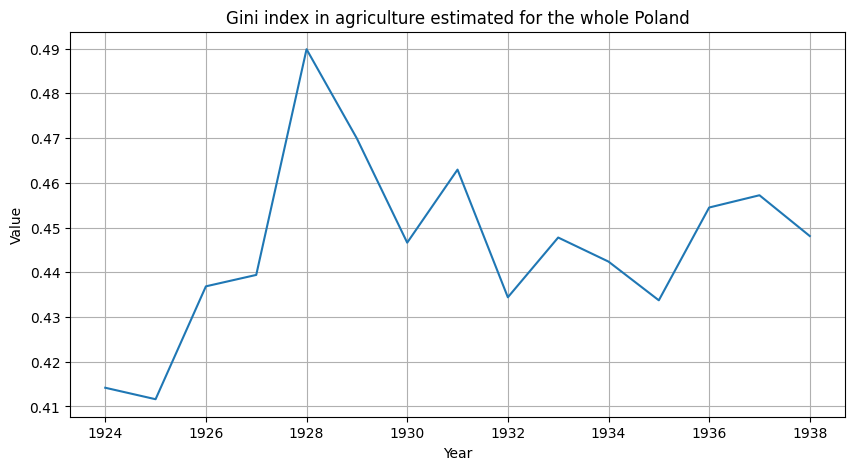

In [125]:
# --- Create Gini line plot ---
plt.figure(figsize=(10, 5))
plt.plot(national_ginis_A.index, national_ginis_A.values)
plt.xlabel("Year")
plt.ylabel("Value")
plt.title("Gini index in agriculture estimated for the whole Poland")
plt.grid(True)

# --- Save the plot to a file ---
plt.savefig(r"E:\OneDrive\Studia\Studia magisterskie\Masterarbeit - Wirtschaftwissenschaft\szaunki_powiatowe_II_RP_corrected\income_inequality_agriculture\national_gini.png", dpi=300, bbox_inches="tight")

national_ginis_A.to_csv(r"E:\OneDrive\Studia\Studia magisterskie\Masterarbeit - Wirtschaftwissenschaft\szaunki_powiatowe_II_RP_corrected\income_inequality_agriculture\national_gini.csv", sep=";", encoding='utf-8')

In [110]:
district_ginis_A[1924]

AUGUSTOWSKI                  0.187380
BARANOWICKI                  0.177656
BIALSKI (BIAŁA KRAKOWSKA)    0.151967
BIALSKI (BIAŁA PODLASKA)     0.181615
BIAŁOSTOCKI                  0.190421
                               ...   
ŚWIĘTOCHŁOWICKI                   NaN
ŻNIŃSKI                      0.290182
ŻYDACZOWSKI                  0.135618
ŻYWIECKI                     0.114615
ŻÓŁKIEWSKI                   0.147398
Name: Gini, Length: 247, dtype: float64

In [ ]:
del data_by_year[1921]
del data_by_year[1922]
del data_by_year[1923]

In [126]:
for year in all_years:
    data_by_year[year]['log_Gini'] = np.log(data_by_year[year]['Gini'])

In [ ]:
# Plot Gini index year by year
plot_year_df_columns(
    adm_history_plotter=adm_history_plotter,
    adm_state_date=reference_date,
    custom_dist_grouping=d_city_mapping,
    plots_output_path=plots_output_path,
    path_suffix = "/income_inequality_agriculture/log_Gini/",
    year_df_dict = data_by_year,
    col_name = 'log_Gini',
    title = 'Log of Gini Index in Agriculture',
    export_excel = True,
    # legend_min=0.05,
    # legend_max=0.65
)

In [ ]:
# Plot Gini index year by year
plot_year_df_columns(
    adm_history_plotter=adm_history_plotter,
    adm_state_date=reference_date,
    custom_dist_grouping=d_city_mapping,
    plots_output_path=plots_output_path,
    path_suffix = "/income_inequality_agriculture/",
    year_df_dict = data_by_year,
    col_name = 'Gini',
    title = 'Gini Index in Agriculture',
    export_excel = True,
    legend_min=0.05,
    legend_max=0.65
)

In [115]:
income_shape.to_csv(r"E:\OneDrive\Studia\Studia magisterskie\Masterarbeit - Wirtschaftwissenschaft\szaunki_powiatowe_II_RP_corrected\income_inequality_agriculture\incomes_per_holding_size.csv", sep=";", encoding = 'utf-8')